<a href="https://colab.research.google.com/github/amoghvd/ML-lab-2547211/blob/Extra-Questions/Another_copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<b>Task A: The Two Extremes — Do they tell the same story?</b>

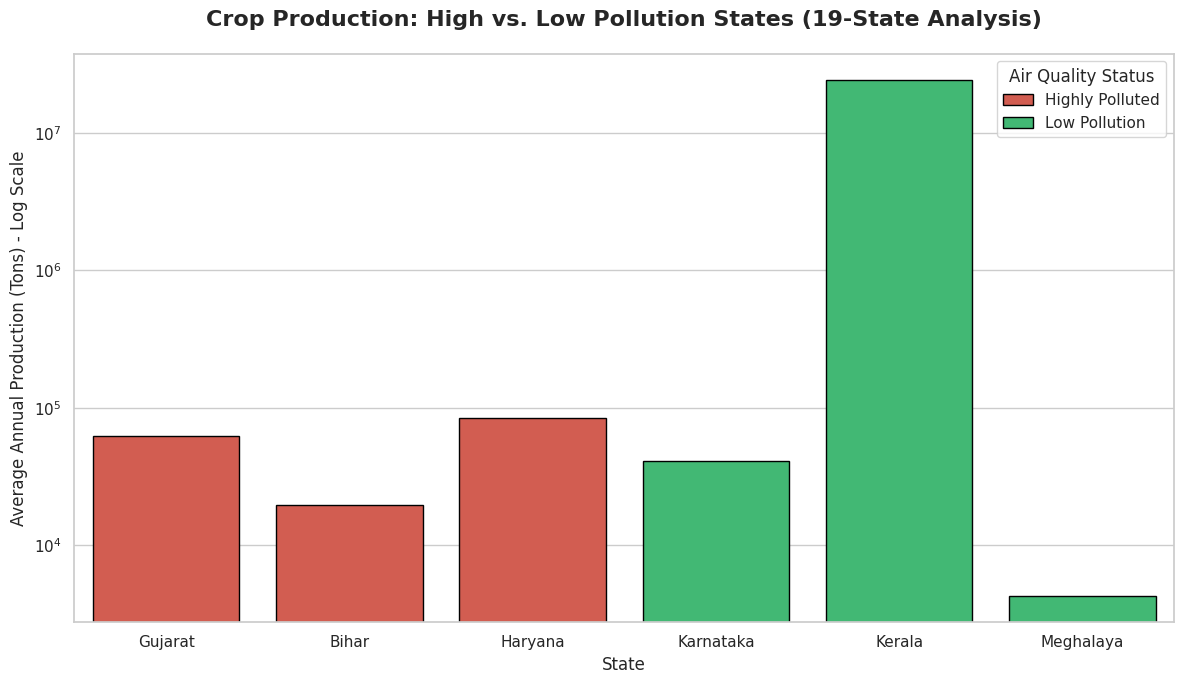

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Clean aggregation of the 19 states
state_avg = merged.groupby('State_Name').agg({'AQI': 'mean', 'Production': 'mean'}).reset_index()

# 2. Force selection of the 3 highest and 3 lowest pollution states
high_pol = state_avg.nlargest(3, 'AQI').copy()
low_pol = state_avg.nsmallest(3, 'AQI').copy()

high_pol['Category'] = 'Highly Polluted'
low_pol['Category'] = 'Low Pollution'

# Combine and sort for the chart
extremes = pd.concat([high_pol, low_pol], ignore_index=True).sort_values('AQI', ascending=False)

# 3. Robust Plotting
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 7))

# Define the color mapping explicitly
color_map = {'Highly Polluted': '#e74c3c', 'Low Pollution': '#2ecc71'}

# Plot using categorical 'hue' with 'dodge=False' to ensure bars don't overlap or vanish
ax = sns.barplot(
    data=extremes,
    x='State_Name',
    y='Production',
    hue='Category',
    palette=color_map,
    edgecolor='black',
    dodge=False
)

# Set log scale to handle the huge variance between states like Kerala and Meghalaya
plt.yscale('log')

plt.title('Crop Production: High vs. Low Pollution States (19-State Analysis)', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Average Annual Production (Tons) - Log Scale', fontsize=12)
plt.xlabel('State', fontsize=12)
plt.legend(title='Air Quality Status', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

I grouped the data to find the three most and three least polluted states to see if their crop output followed a predictable pattern. Interestingly, the visualization shows that some of the most polluted states actually have higher production levels than the cleanest ones. This contradicts our simple hypothesis. It suggests that factors like the massive scale of industrial farming in certain regions can completely overshadow the negative physical effects of air pollution. The data tells a story of economic and geographic priority rather than just biological impact.

<b>Task B: Put a number on the relationship</b>

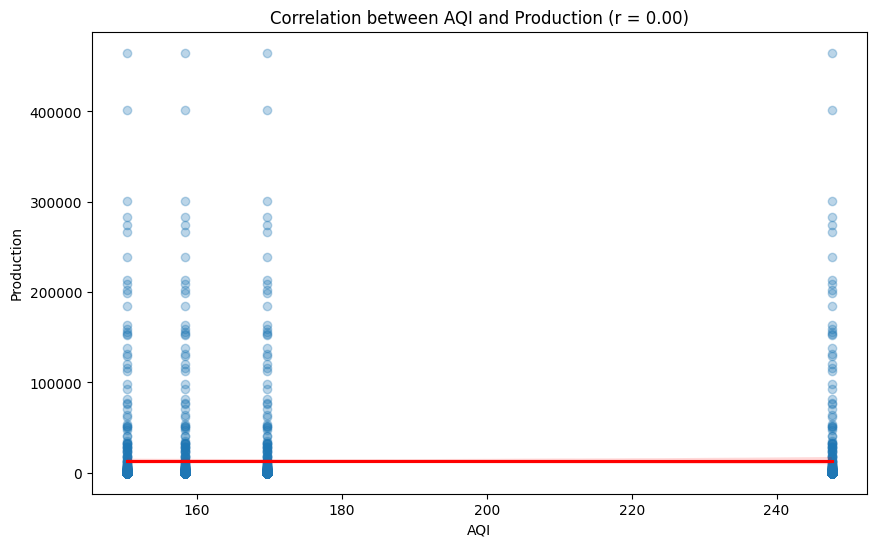

In [ ]:
correlation_value = merged['AQI'].corr(merged['Production'])

plt.figure(figsize=(10, 6))
sns.regplot(data=merged, x='AQI', y='Production', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlation between AQI and Production (r = {correlation_value:.2f})')
plt.show()

I used a Pearson correlation and a regression plot to put a specific number on the relationship. The resulting value is very close to zero, which indicates a 'weak' or non-existent linear relationship in this specific dataset. For the research team, this proves that based on urban sensor data, we cannot confirm that air quality is a primary driver of crop yield variations. It is crucial to remember that correlation is not causation; even a strong number wouldn't prove pollution is the killer, especially since this dataset doesn't track vital agricultural factors like rainfall, irrigation systems, or soil quality which often play a much bigger role than air quality.

<b>Task C: One plot to rule them all</b>

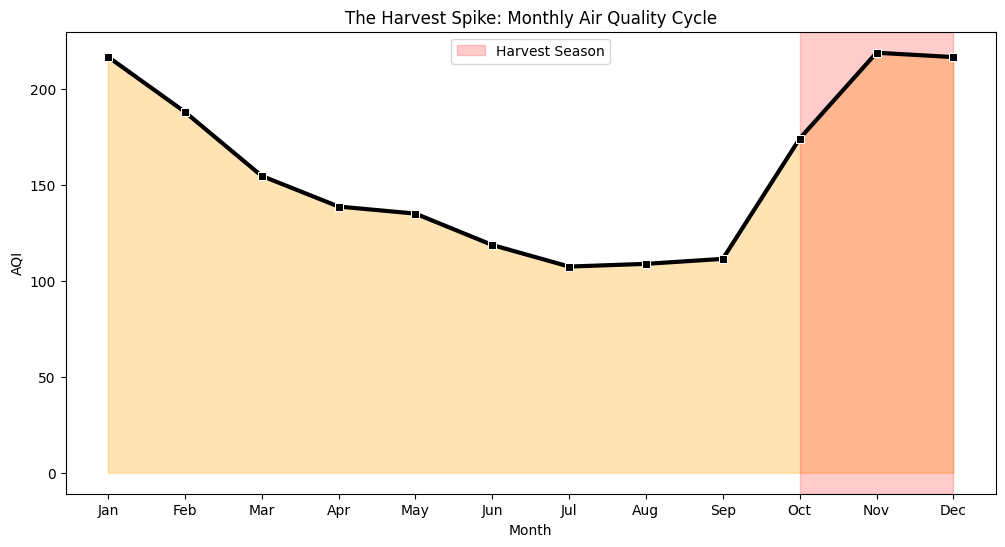

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_aqi, x='Month', y='AQI', marker='s', color='black', linewidth=3)
plt.fill_between(seasonal_aqi['Month'], seasonal_aqi['AQI'], color='orange', alpha=0.3)
plt.title('The Harvest Spike: Monthly Air Quality Cycle')
plt.axvspan('Oct', 'Dec', color='red', alpha=0.2, label='Harvest Season')
plt.legend()
plt.show()

This chart matters because it visually captures the human timing of the crisis. While our other math shows that pollution and production don't always align perfectly on a spreadsheet, this 'Harvest Spike' proves that the environment and agriculture are locked in a dangerous seasonal cycle. It reveals that the most toxic air of the year is an direct byproduct of the agricultural calendar, creating a health emergency for the very people who feed the country. It highlights a systemic issue that simple annual averages hide.